<a href="https://colab.research.google.com/github/Rudi1410/BigData_Spotify/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Spotify Charts Daily Updated
**Dataset:** gonzalopezgil/spotify-charts-daily-updated (Kaggle)  


---


## Tahap 0 — Instalasi & Import

In [ ]:
!pip install kagglehub missingno -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import os
import warnings
import random
import gc

warnings.filterwarnings('ignore')

---
## Tahap 1 — Load Dataset

### 1.1 Download dari Kaggle

In [ ]:
path = kagglehub.dataset_download("gonzalopezgil/spotify-charts-daily-updated")
print("Path dataset:", path)

Using Colab cache for faster access to the 'spotify-charts-daily-updated' dataset.
Path dataset: /kaggle/input/spotify-charts-daily-updated


### 1.2 Baca Semua File CSV

In [ ]:
CHUNK_SIZE = 10000

summary_rows = []

for f in sorted(os.listdir(path)):
    if not f.endswith(".csv"):
        continue

    fpath = os.path.join(path, f)

    total_rows = 0
    total_missing = 0
    total_duplicates = 0
    columns = None

    for chunk in pd.read_csv(fpath, chunksize=CHUNK_SIZE):

        total_rows += len(chunk)

        total_missing += chunk.isnull().sum().sum()

        total_duplicates += chunk.duplicated().sum()

        if columns is None:
            columns = chunk.shape[1]

    summary_rows.append({
        "File": f,
        "Baris": total_rows,
        "Kolom": columns,
        "Duplikat": total_duplicates,
        "Missing": total_missing,
        "Size (MB)": round(os.path.getsize(fpath)/(1024**2),2)
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,File,Baris,Kolom,Duplikat,Missing,Size (MB)
0,albums.csv,24890,6,0,768,3.29
1,artist_listeners_daily.csv,227824,3,0,0,9.04
2,artists.csv,72371,6,0,211060,4.13
3,artwork.csv,298582,4,0,22438,33.48
4,charts_albums_weekly.csv,2795375,17,0,81513,569.99
5,charts_artists_daily.csv,22948662,13,0,3,2666.08
6,charts_songs_daily.csv,42869655,18,0,770860,10063.01
7,links.csv,135712,10,0,537772,14.08
8,songs.csv,208836,7,0,2620,40.32


### 1.3 Tentukan File Utama

In [ ]:
# File utama yang akan dianalisis secara mendalam
MAIN = 'charts_songs_daily'

fpath = os.path.join(path, f"{MAIN}.csv")

# Ambil sampel acak untuk EDA
SAMPLE_SIZE = 100000
TOTAL_ROWS = 42869655  # sesuai hasil summary

df = pd.read_csv(
    fpath,
    skiprows=lambda x: x > 0 and np.random.rand() > SAMPLE_SIZE/TOTAL_ROWS,
    low_memory=True
)

print("File utama :", MAIN)
print("Shape      :", df.shape)
print("Kolom      :", list(df.columns))

File utama : charts_songs_daily
Shape      : (100062, 18)
Kolom      : ['date', 'country', 'rank', 'uri', 'artist_names', 'track_name', 'label', 'peak_rank', 'previous_rank', 'days_on_chart', 'streams', 'consecutive_days', 'entry_status', 'peak_date', 'entry_rank', 'entry_date', 'release_date', 'artist_uris']


---
## Tahap 2 — Data Overview

### 2.1 Tampilan Awal Data

In [ ]:
df.head()

,date,country,rank,uri,artist_names,track_name,label,peak_rank,previous_rank,days_on_chart,streams,consecutive_days,entry_status,peak_date,entry_rank,entry_date,release_date,artist_uris
0,2019-06-10,ae,54,spotify:track:2BgEsaKNfHUdlh97KmvFyo,Anne-Marie,2002,Atlantic Records UK,54,54,4,1125,3,NO_CHANGE,2019-06-09,108,2019-06-06,2018-04-27,spotify:artist:1zNqDE7qDGCsyzJwohVaoX
1,2019-06-13,ae,28,spotify:track:4QuIM0B9hR9FYJRCcKGvtb,Mahmoud Al Turky,Dommeny Dommeny,Alnojomia,14,38,9,1679,9,MOVED_UP,2019-06-05,14,2019-06-05,2019-03-15,spotify:artist:1GVRoyErxhZGdvmOKGO7W7
2,2019-06-25,ae,10,spotify:track:6LsAAHotRLMOHfCsSfYCsz,Shawn Mendes,If I Can't Have You,Island Records,5,10,22,2710,22,NO_CHANGE,2019-06-09,6,2019-06-04,2019-05-03,spotify:artist:7n2wHs1TKAczGzO7Dd2rGr
3,2019-06-30,ae,33,spotify:track:0DiDStADDVh3SvAsoJAFMk,Jonas Brothers,Only Human,Jonas Brothers Recording,31,35,24,1838,24,MOVED_UP,2019-06-10,86,2019-06-07,2019-06-07,spotify:artist:7gOdHgIoIKoe4i9Tta6qdD
4,2019-07-02,ae,69,spotify:track:2P91MQbaiQOfbiz9VqhqKQ,Lauv,I Like Me Better,Lauv,34,64,29,1272,29,MOVED_DOWN,2019-06-11,35,2019-06-04,2018-05-31,spotify:artist:5JZ7CnR6gTvEMKX4g70Amv


In [ ]:
df.tail()

,date,country,rank,uri,artist_names,track_name,label,peak_rank,previous_rank,days_on_chart,streams,consecutive_days,entry_status,peak_date,entry_rank,entry_date,release_date,artist_uris
100057,2026-05-25,za,163,spotify:track:31kxPC3ZB9AYwCLyHaqEVX,Tems,Me & U,RCA Records/Since 93',18,187,563,14949,9,MOVED_UP,2024-01-10,156,2023-10-05,2024-06-06,spotify:artist:687cZJR45JO7jhk1LHIbgq
100058,2026-05-25,za,196,spotify:track:58WLvZupttesFG6fXD4neJ,JIKIJIKI,Sengiqomile,JIKIJIKI MUSIC PRODUCTION,128,-1,7,13625,1,RE_ENTRY,2026-05-20,181,2026-05-04,2026-05-01,spotify:artist:4Bv7LRWfDAcI13VW6SNF94
100059,2026-05-27,za,90,spotify:track:6Rr4HJll7Yckt0sGDokse9,N T S A K O XVI|Shaun 101|Uncool MC|Ch'cco|Sco...,NGEKE (feat. Scotts Maphuma),101 Music / EMPIRE,12,99,34,21686,34,MOVED_UP,2026-05-08,127,2026-04-24,2026-04-23,spotify:artist:4nZhRvCMJPp7Y9t64bHAPb|spotify:...
100060,2026-05-27,za,197,spotify:track:5Y77SQxEr1eiofPeUTPHxM,Lloyd|Lil Wayne,You,"I.G. Records, Inc./Universal Records",94,182,278,14175,2,MOVED_DOWN,2026-05-07,194,2024-08-21,2007-01-01,spotify:artist:1Xfmvd48oOhEWkscWyEbh9|spotify:...
100061,2026-05-28,za,19,spotify:track:3UpOAGqJltveyi8DQYr0WI,Sam Deep|Nia Pearl|Boohle|Mano,Shela,Universal Music (Pty) Ltd.,1,24,281,44462,277,MOVED_UP,2025-10-14,97,2025-08-08,2025-12-05,spotify:artist:46R9PUVbIOMjSUtMsQZbQq|spotify:...


### 2.2 Tipe Data & Penggunaan Memori

In [ ]:
print(f"Shape  : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print(df.dtypes)

Shape  : 100,062 baris x 18 kolom
Memory : 76.13 MB

date                object
country             object
rank                 int64
uri                 object
artist_names        object
track_name          object
label               object
peak_rank            int64
previous_rank        int64
days_on_chart        int64
streams              int64
consecutive_days     int64
entry_status        object
peak_date           object
entry_rank           int64
entry_date          object
release_date        object
artist_uris         object
dtype: object


### 2.3 Statistik Deskriptif

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Kolom Numerik  :", num_cols if num_cols else "Tidak ada")
print("Kolom Kategori :", cat_cols)

Kolom Numerik  : ['rank', 'peak_rank', 'previous_rank', 'days_on_chart', 'streams', 'consecutive_days', 'entry_rank']
Kolom Kategori : ['date', 'country', 'uri', 'artist_names', 'track_name', 'label', 'entry_status', 'peak_date', 'entry_date', 'release_date', 'artist_uris']


In [ ]:
if num_cols:
    display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
rank,100062.0,98.198997,57.630752,1.0,48.0,97.0,148.00,200.0
peak_rank,100062.0,34.445064,39.215312,1.0,5.0,18.0,53.00,200.0
previous_rank,100062.0,87.176421,58.545582,-1.0,36.0,85.0,136.00,200.0
days_on_chart,100062.0,264.718634,356.534698,1.0,46.0,138.0,334.00,3418.0
streams,100062.0,68276.246917,249874.427388,1001.0,4787.0,12180.0,44805.75,13234766.0
consecutive_days,100062.0,129.011733,208.257870,1.0,11.0,55.0,161.00,3418.0
entry_rank,100062.0,102.423158,70.034820,1.0,33.0,103.0,174.00,200.0


In [ ]:
for col in cat_cols:
    n_unique = df[col].nunique()
    top_val  = df[col].value_counts().idxmax()
    top_freq = df[col].value_counts().iloc[0]
    print(f"{col:<30}  unique={n_unique:>7,}   top='{str(top_val)[:45]}'  ({top_freq:,}x)")

date                            unique=  3,435   top='2023-04-11'  (59x)
country                         unique=     73   top='tw'  (1,698x)
uri                             unique= 33,028   top='spotify:track:0VjIjW4GlUZAMYd2vXMi3b'  (209x)
artist_names                    unique= 18,144   top='Bad Bunny'  (1,287x)
track_name                      unique= 28,442   top='Blinding Lights'  (225x)
label                           unique=  6,832   top='Columbia'  (3,569x)
entry_status                    unique=      5   top='MOVED_DOWN'  (44,237x)
peak_date                       unique=  3,435   top='2017-01-01'  (1,140x)
entry_date                      unique=  3,425   top='2017-01-01'  (5,123x)
release_date                    unique=  4,678   top='2022-05-06'  (599x)
artist_uris                     unique= 18,170   top='spotify:artist:4q3ewBCX7sLwd24euuV69X'  (1,287x)


---
## Tahap 3 — Data Cleaning

### 3.1 Cek Missing Values

In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

miss_df = pd.DataFrame({
    'Jumlah Missing' : missing,
    'Persentase (%)'  : missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print("Missing values per kolom:")
display(miss_df)

Missing values per kolom:


,Jumlah Missing,Persentase (%)
release_date,1467,1.47
track_name,104,0.10
artist_names,103,0.10
label,101,0.10
country,0,0.00
date,0,0.00
rank,0,0.00
peak_rank,0,0.00
previous_rank,0,0.00
uri,0,0.00


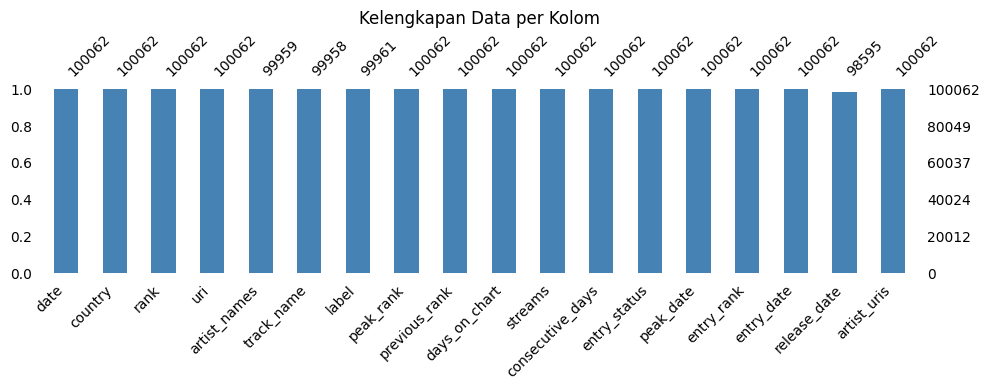

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
msno.bar(df, ax=ax, fontsize=10, color='steelblue')
ax.set_title('Kelengkapan Data per Kolom')
plt.tight_layout()
plt.show()

### 3.2 Cek Duplikat

In [ ]:
dup_total = df.duplicated().sum()
print(f"Jumlah baris duplikat : {dup_total:,}")
print(f"Persentase            : {dup_total / len(df) * 100:.2f}%")

if dup_total > 0:
    display(df[df.duplicated(keep=False)].head(4))

Jumlah baris duplikat : 0
Persentase            : 0.00%


### 3.3 Konversi Tipe Data

In [ ]:
# Konversi kolom tanggal ke datetime
for col in ['release_date', 'date', 'chart_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"{col} -> datetime  |  NaT: {df[col].isna().sum():,}")

# Konversi kolom angka yang tersimpan sebagai string
for col in ['streams', 'rank', 'peak_rank', 'weeks_on_chart', 'listeners', 'followers', 'popularity']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"{col} -> numeric")

print()
print("Tipe data setelah konversi:")
print(df.dtypes)

release_date -> datetime  |  NaT: 1,467
date -> datetime  |  NaT: 0
streams -> numeric
rank -> numeric
peak_rank -> numeric

Tipe data setelah konversi:
date                datetime64[ns]
country                     object
rank                         int64
uri                         object
artist_names                object
track_name                  object
label                       object
peak_rank                    int64
previous_rank                int64
days_on_chart                int64
streams                      int64
consecutive_days             int64
entry_status                object
peak_date                   object
entry_rank                   int64
entry_date                  object
release_date        datetime64[ns]
artist_uris                 object
dtype: object


### 3.4 Hapus Duplikat

In [ ]:
sebelum = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f"Baris sebelum : {sebelum:,}")
print(f"Baris sesudah : {sesudah:,}")
print(f"Terhapus      : {sebelum - sesudah:,}")
print(f"Shape akhir   : {df.shape}")

Baris sebelum : 100,062
Baris sesudah : 100,062
Terhapus      : 0
Shape akhir   : (100062, 18)


---
## Tahap 4 — Univariate Analysis

### 4.1 Distribusi Kolom Numerik

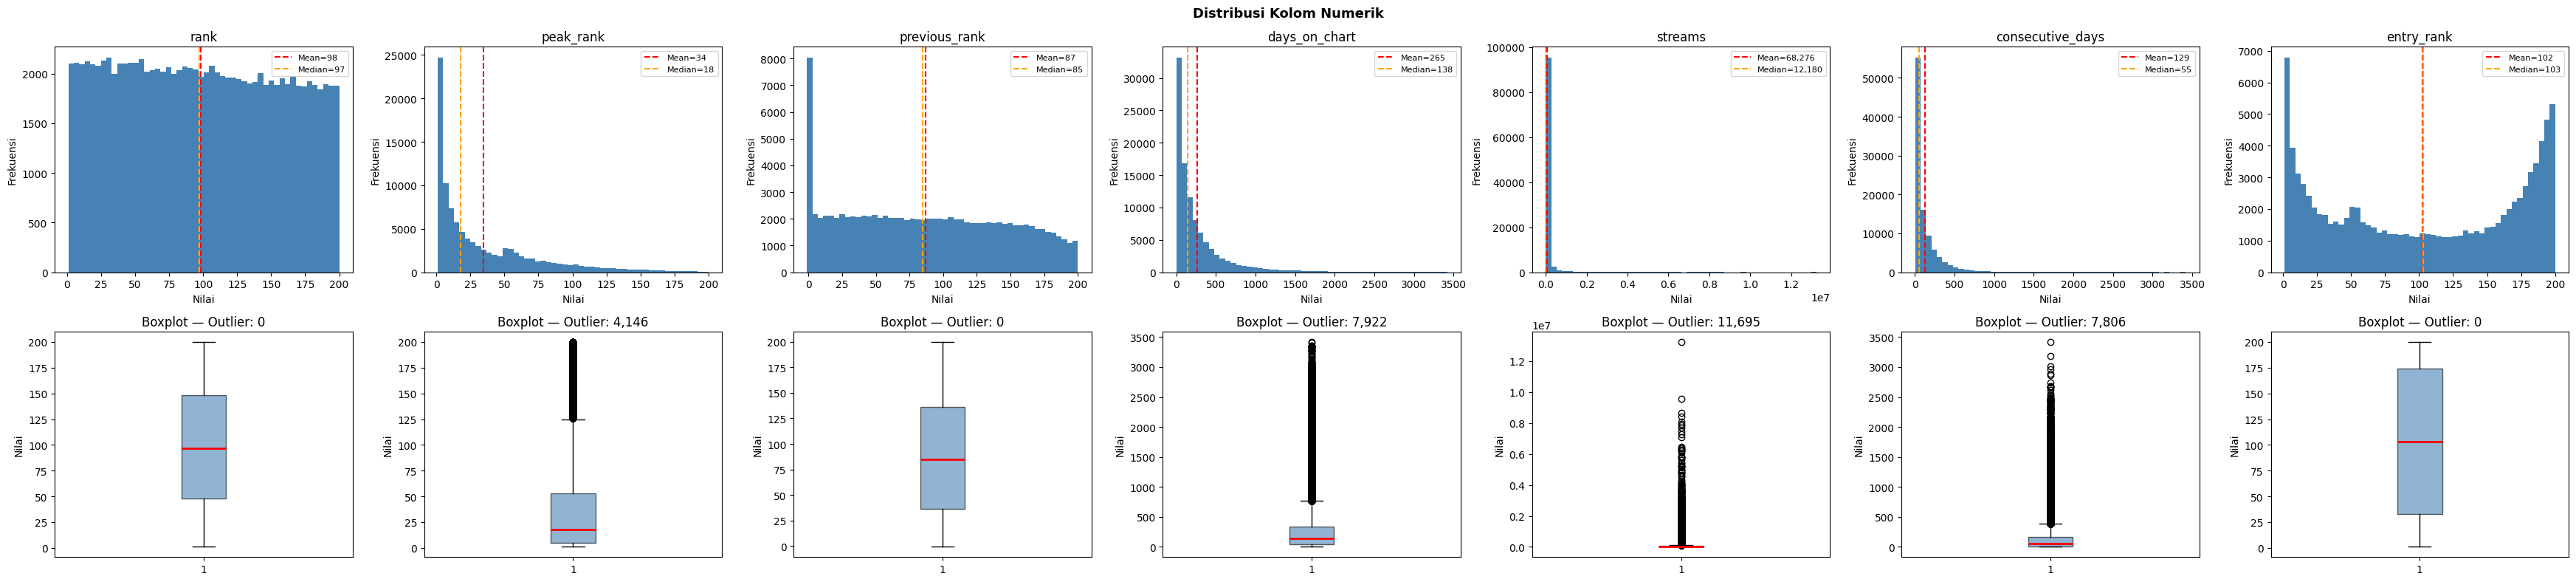

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()

if num_cols:
    fig, axes = plt.subplots(2, len(num_cols), figsize=(5 * len(num_cols), 8))
    if len(num_cols) == 1:
        axes = axes.reshape(2, 1)

    for i, col in enumerate(num_cols):
        data = df[col].dropna()

        axes[0][i].hist(data, bins=50, color='steelblue', edgecolor='none')
        axes[0][i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={data.mean():,.0f}')
        axes[0][i].axvline(data.median(), color='orange', linestyle='--', lw=1.5, label=f'Median={data.median():,.0f}')
        axes[0][i].set_title(col)
        axes[0][i].set_xlabel('Nilai')
        axes[0][i].set_ylabel('Frekuensi')
        axes[0][i].legend(fontsize=8)

        bp = axes[1][i].boxplot(data, patch_artist=True,
                                medianprops=dict(color='red', linewidth=2))
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.6)
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        n_out  = ((data < q1 - 1.5*(q3-q1)) | (data > q3 + 1.5*(q3-q1))).sum()
        axes[1][i].set_title(f'Boxplot — Outlier: {n_out:,}')
        axes[1][i].set_ylabel('Nilai')

    plt.suptitle('Distribusi Kolom Numerik', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom numerik pada file ini.")
    print("Seluruh kolom bertipe string — analisis dilanjutkan ke bagian kategorikal.")

### 4.2 Distribusi Kolom Kategorikal

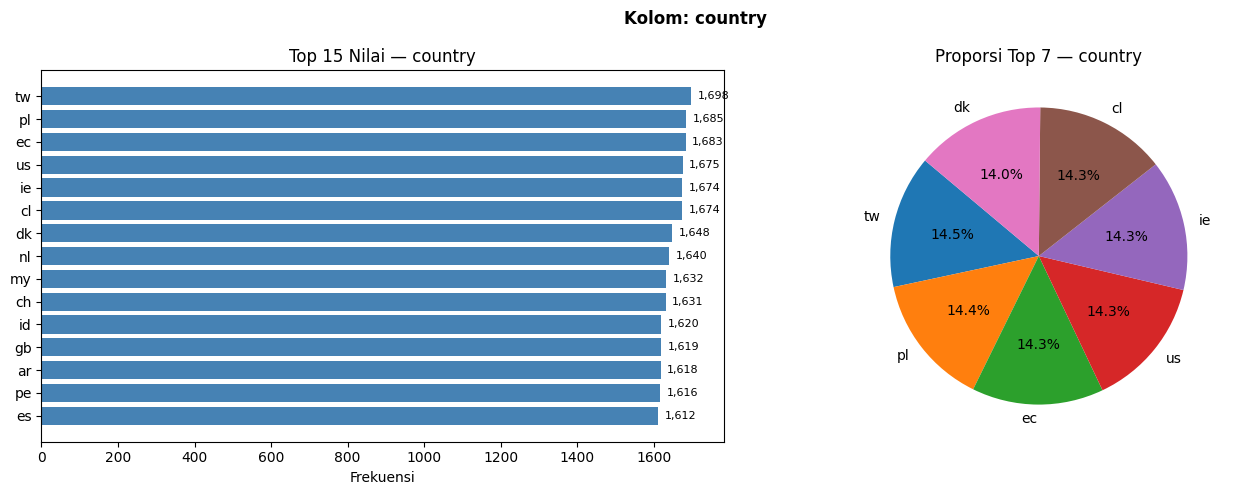

  unique: 73  |  missing: 0



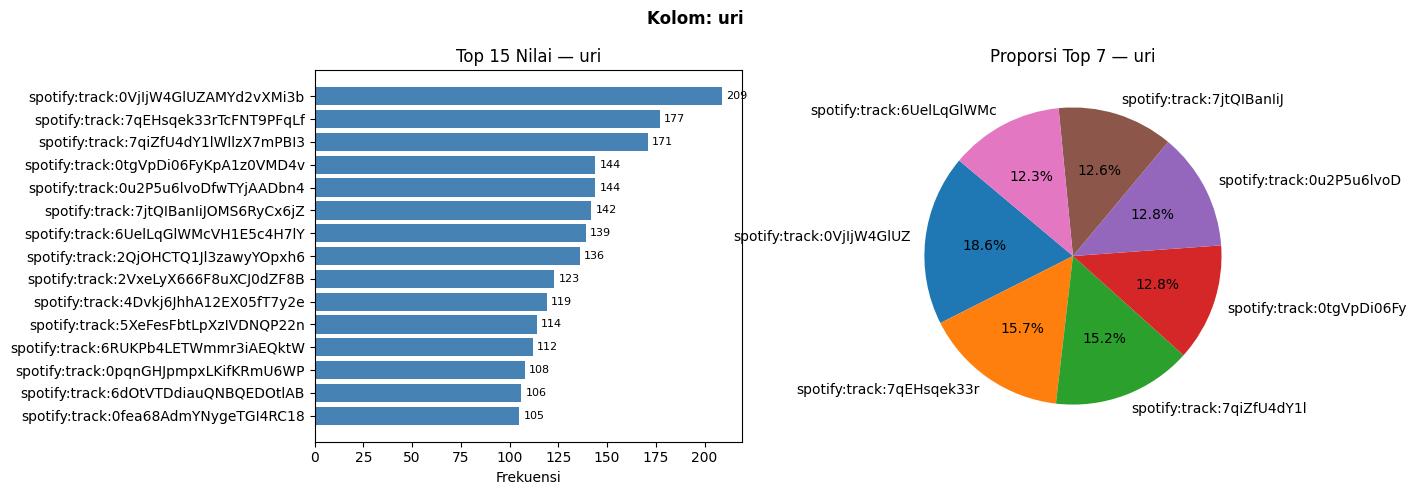

  unique: 33,028  |  missing: 0



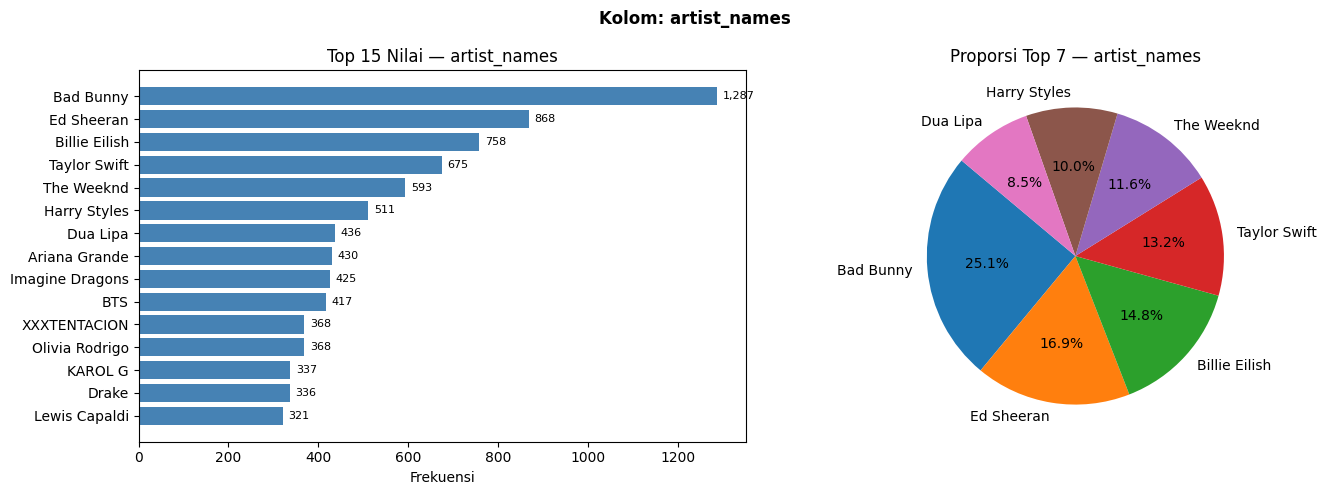

  unique: 18,144  |  missing: 103



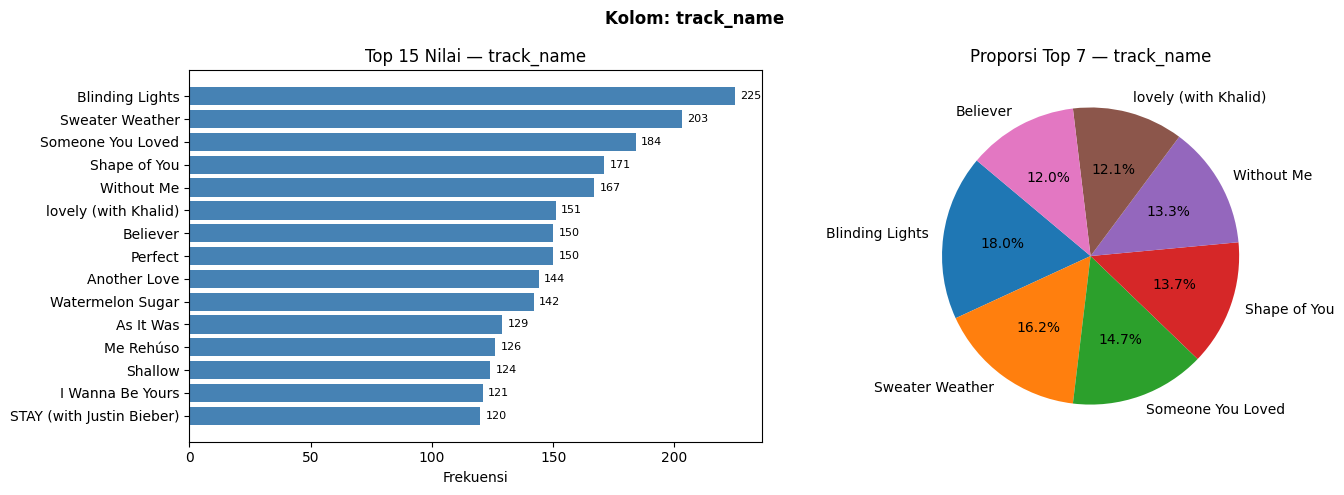

  unique: 28,442  |  missing: 104



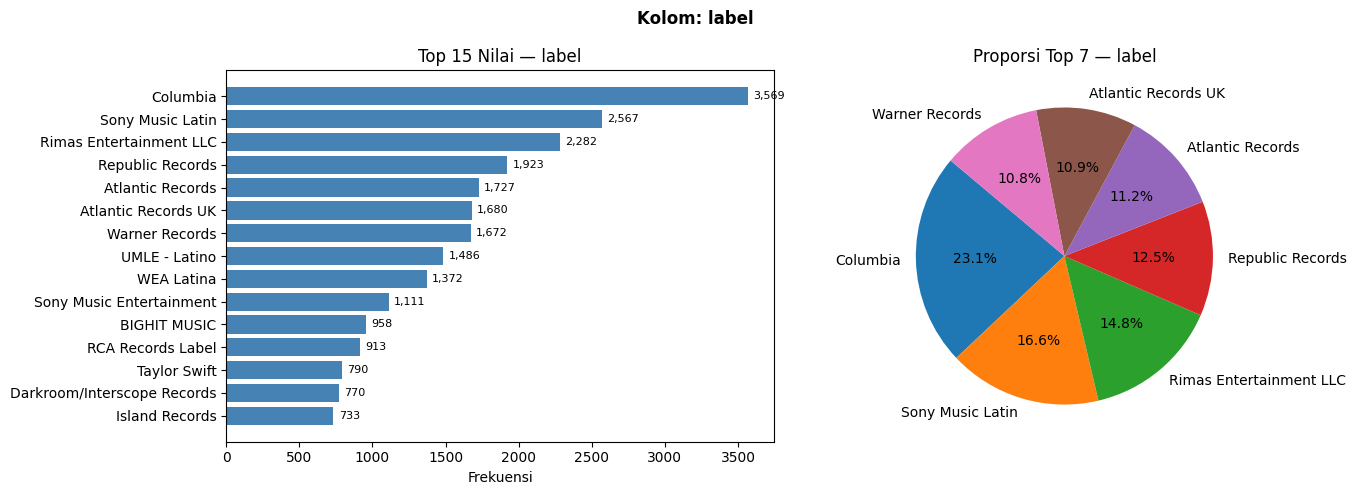

  unique: 6,832  |  missing: 101



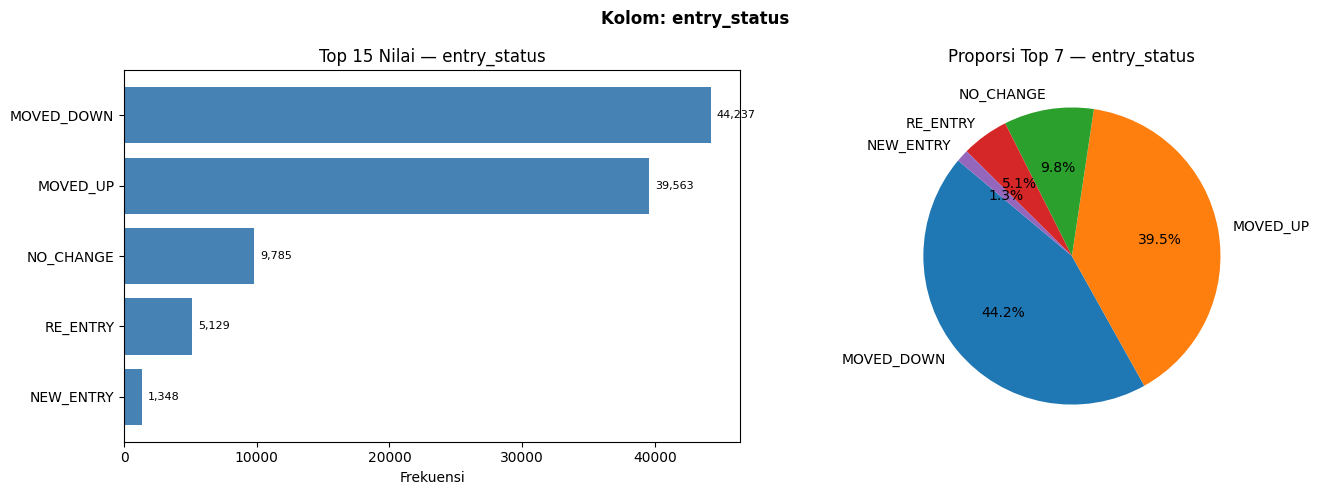

  unique: 5  |  missing: 0



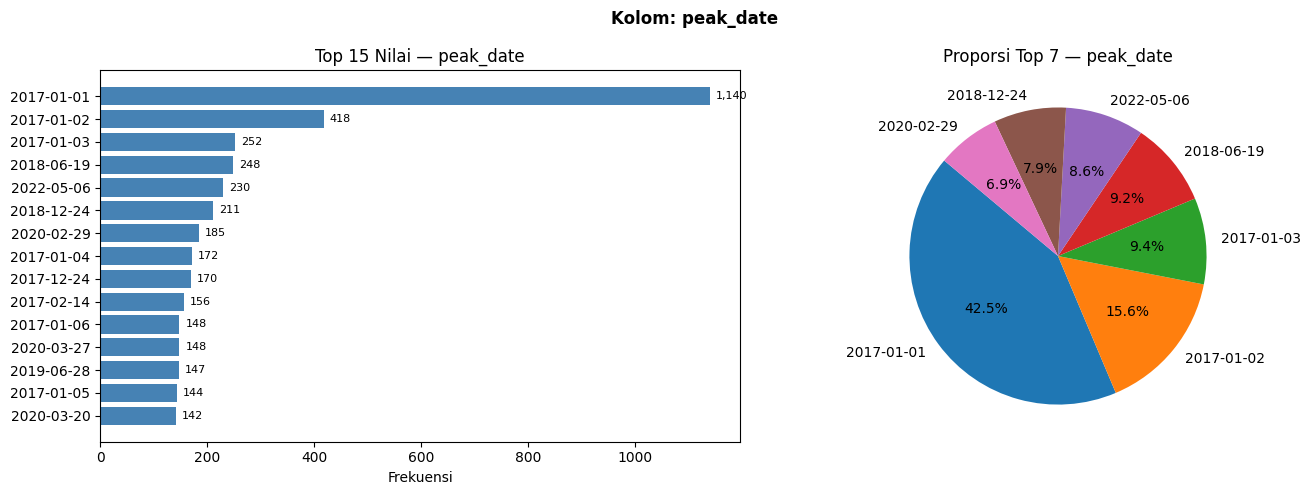

  unique: 3,435  |  missing: 0



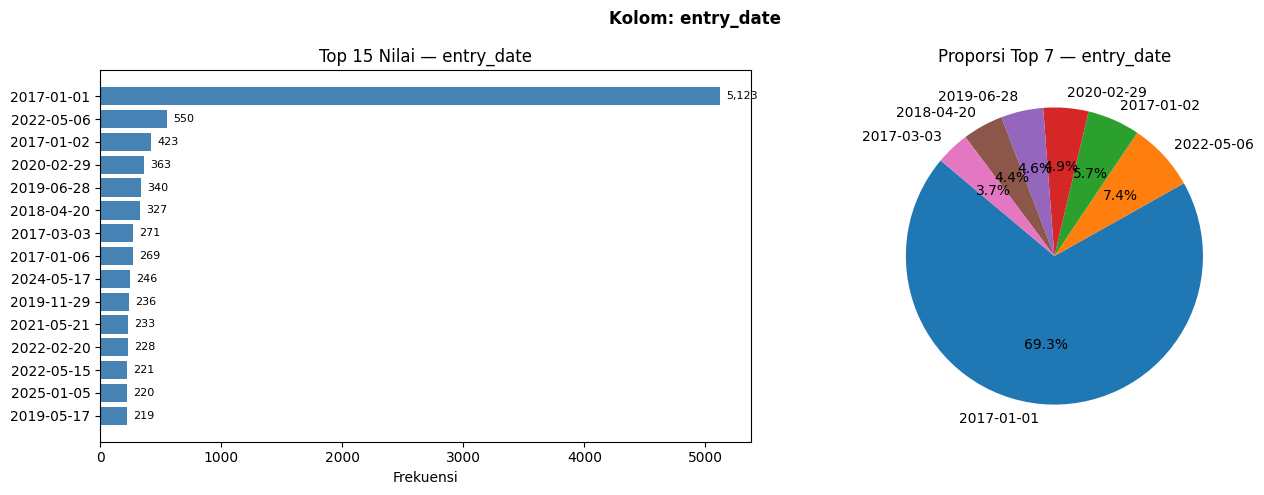

  unique: 3,425  |  missing: 0



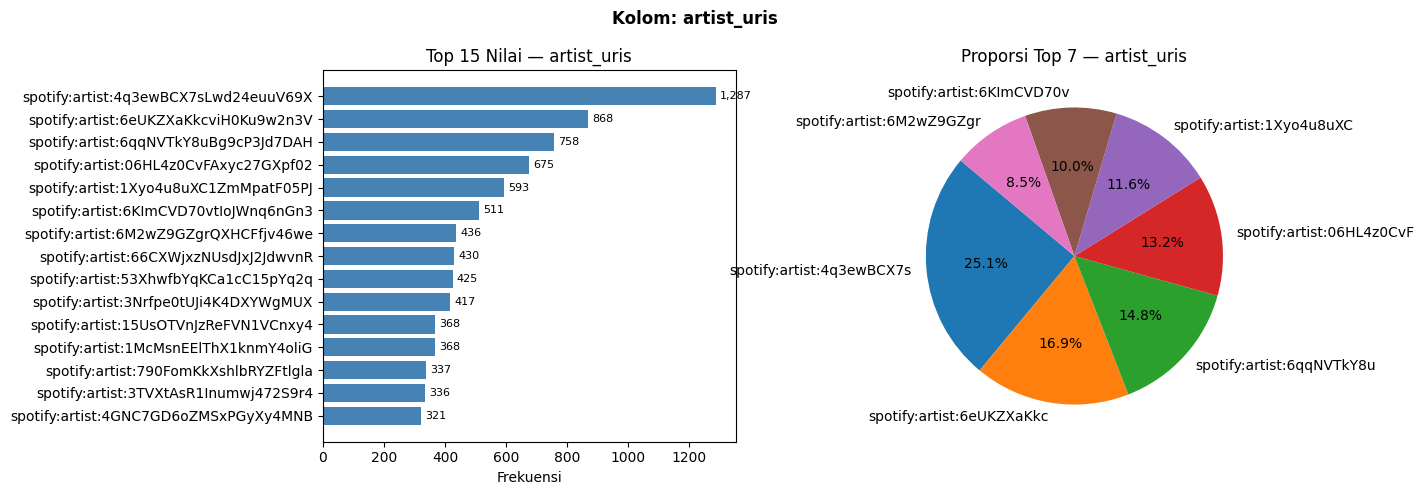

  unique: 18,170  |  missing: 0



In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
TOP_N    = 15

for col in cat_cols:
    vc = df[col].value_counts().head(TOP_N)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(vc.index[::-1], vc.values[::-1], color='steelblue')
    axes[0].set_title(f'Top {TOP_N} Nilai — {col}')
    axes[0].set_xlabel('Frekuensi')
    for bar in axes[0].patches:
        axes[0].text(bar.get_width() + vc.max() * 0.01,
                     bar.get_y() + bar.get_height() / 2,
                     f'{int(bar.get_width()):,}', va='center', fontsize=8)

    pie_data = vc.head(7)
    axes[1].pie(pie_data.values,
                labels=[str(l)[:25] for l in pie_data.index],
                autopct='%1.1f%%', startangle=140)
    axes[1].set_title(f'Proporsi Top 7 — {col}')

    plt.suptitle(f'Kolom: {col}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  unique: {df[col].nunique():,}  |  missing: {df[col].isna().sum():,}")
    print()

### 4.3 Distribusi Tahun Rilis

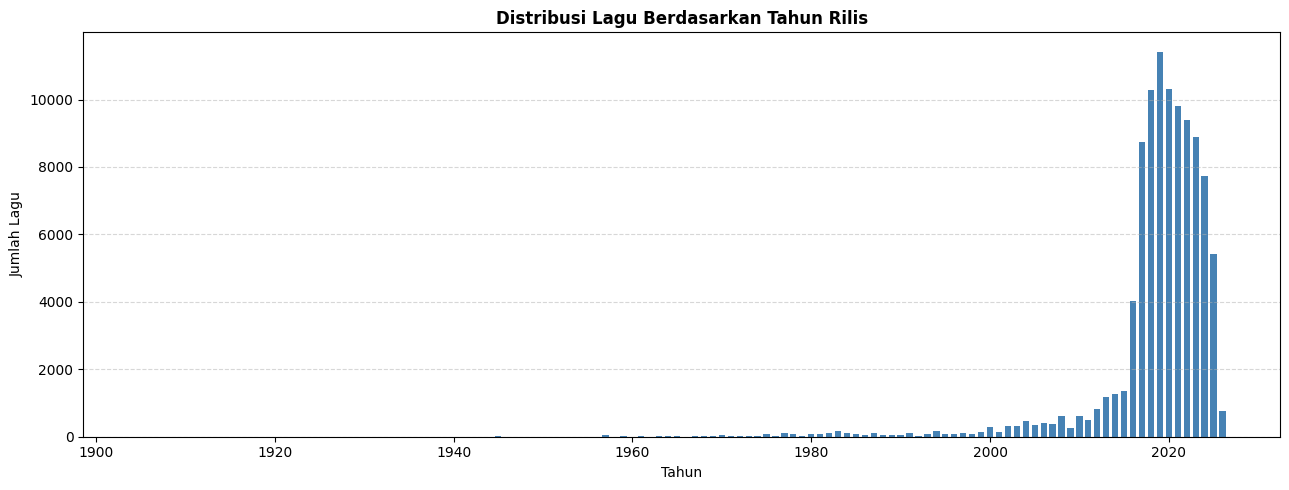

Tahun terbanyak : 2019.0 (11,422 lagu)
Rentang tahun   : 1905 - 2026


In [ ]:
date_col = next((c for c in ['release_date', 'date', 'chart_date']
                 if c in df.columns and pd.api.types.is_datetime64_any_dtype(df[c])), None)

if date_col:
    df['release_year'] = df[date_col].dt.year
    year_dist = df['release_year'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(year_dist.index, year_dist.values, color='steelblue', width=0.7)
    ax.set_title('Distribusi Lagu Berdasarkan Tahun Rilis', fontweight='bold')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Jumlah Lagu')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Tahun terbanyak : {year_dist.idxmax()} ({year_dist.max():,} lagu)")
    print(f"Rentang tahun   : {int(year_dist.index.min())} - {int(year_dist.index.max())}")
else:
    print("Kolom datetime tidak ditemukan atau belum dikonversi.")

---
## Tahap 5 — Bivariate Analysis

### 5.1 Top 15 Artist vs Frekuensi di Chart

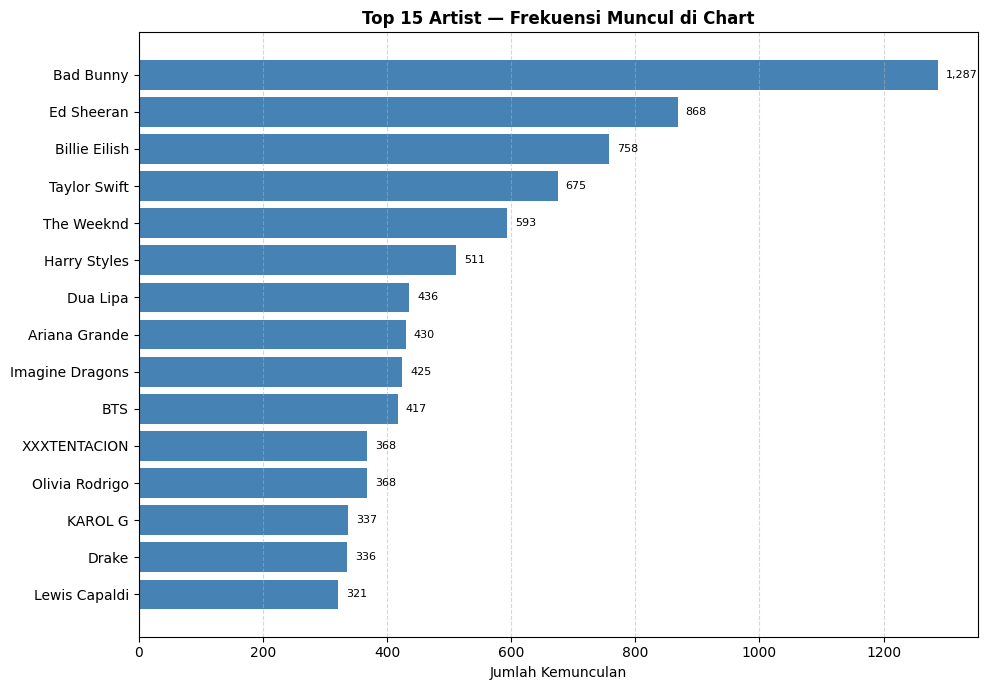

In [ ]:
if 'artist_names' in df.columns:
    top_artists = df['artist_names'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_artists.index[::-1], top_artists.values[::-1], color='steelblue')
    ax.set_title('Top 15 Artist — Frekuensi Muncul di Chart', fontweight='bold')
    ax.set_xlabel('Jumlah Kemunculan')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for bar in ax.patches:
        ax.text(bar.get_width() + top_artists.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

### 5.2 Top 15 Lagu vs Frekuensi di Chart

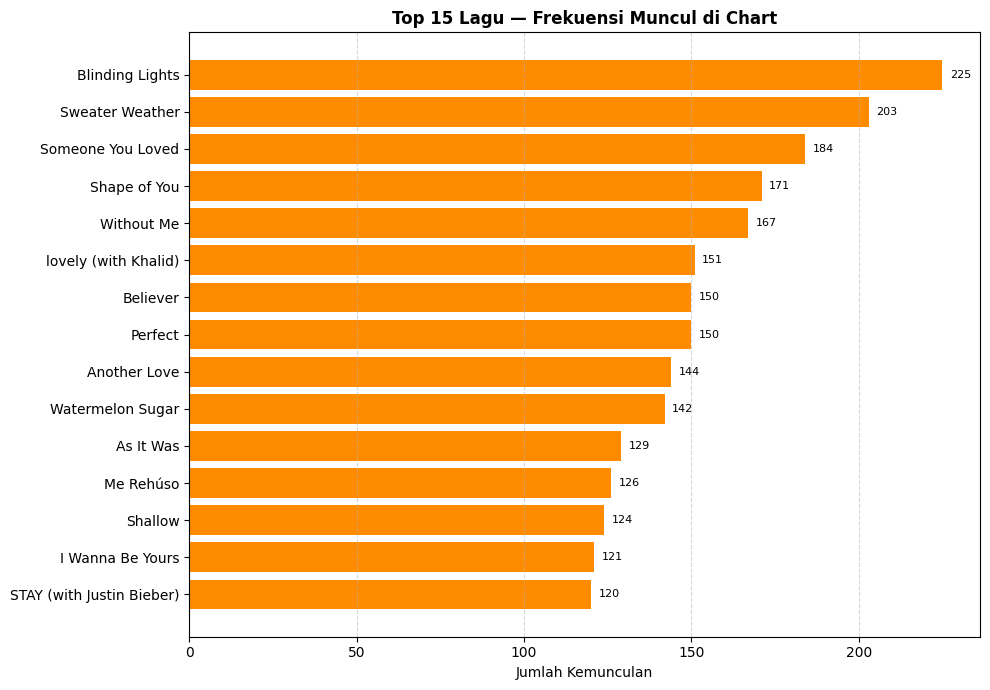

In [ ]:
if 'track_name' in df.columns:
    top_tracks = df['track_name'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_tracks.index[::-1], top_tracks.values[::-1], color='darkorange')
    ax.set_title('Top 15 Lagu — Frekuensi Muncul di Chart', fontweight='bold')
    ax.set_xlabel('Jumlah Kemunculan')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for bar in ax.patches:
        ax.text(bar.get_width() + top_tracks.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

### 5.3 Label Musik vs Jumlah Lagu

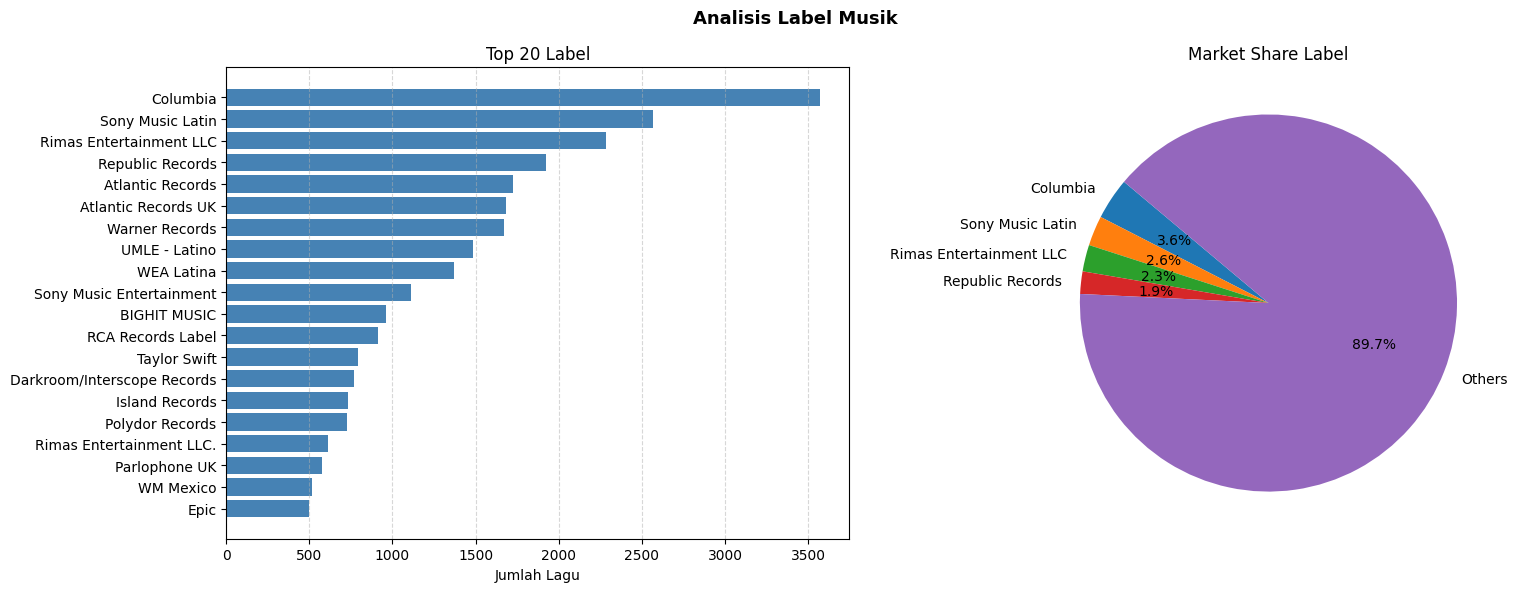

In [ ]:
if 'label' in df.columns:
    top_labels = df['label'].value_counts().head(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Analisis Label Musik', fontsize=13, fontweight='bold')

    axes[0].barh(top_labels.index[::-1], top_labels.values[::-1], color='steelblue')
    axes[0].set_title('Top 20 Label')
    axes[0].set_xlabel('Jumlah Lagu')
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)

    pie_vals = list(top_labels.head(4).values) + [df['label'].notna().sum() - top_labels.head(4).sum()]
    pie_labs = [str(l)[:25] for l in top_labels.head(4).index] + ['Others']
    axes[1].pie(pie_vals, labels=pie_labs, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('Market Share Label')

    plt.tight_layout()
    plt.show()

### 5.4 Scatter Plot Antar Kolom Numerik

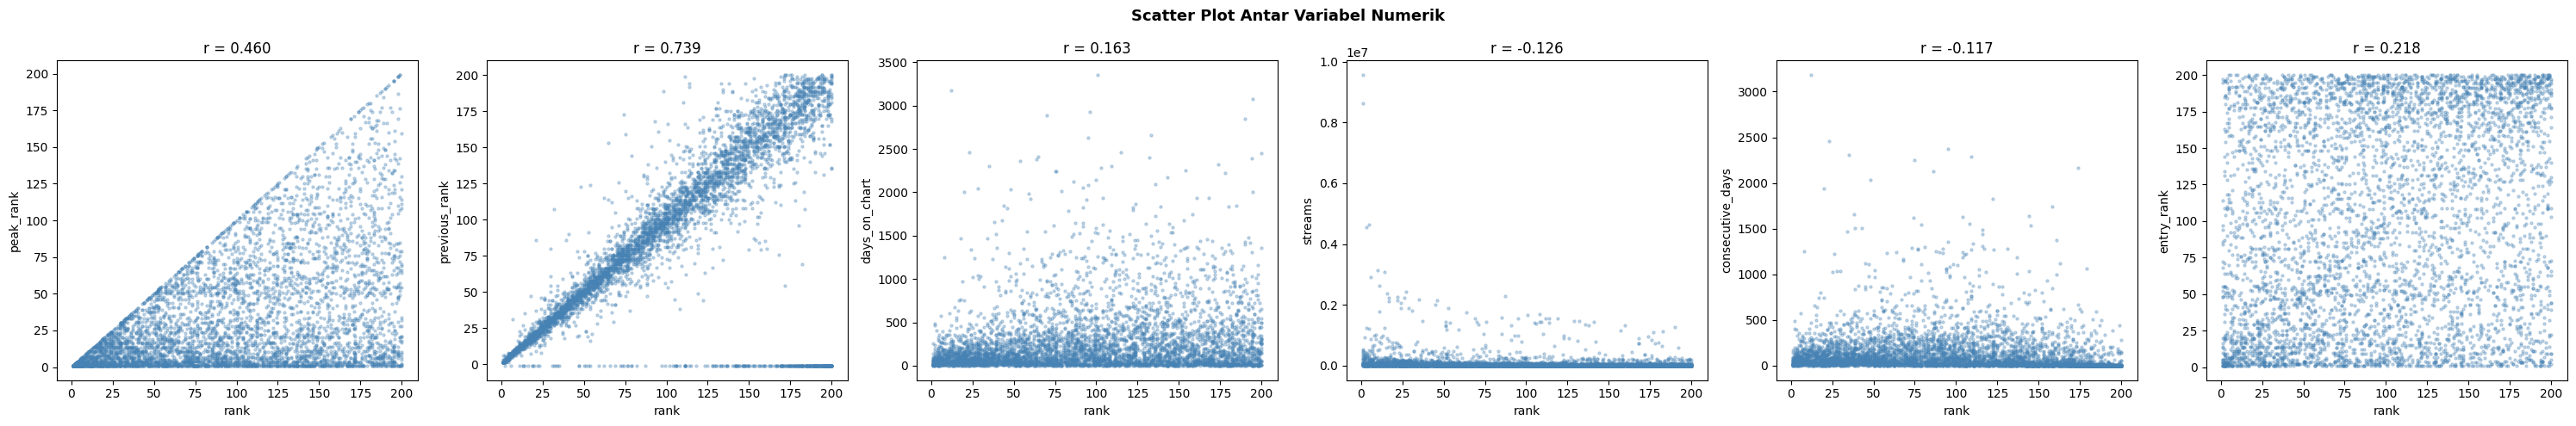

In [ ]:
from itertools import combinations

num_cols = df.select_dtypes(include='number').columns.tolist()

if len(num_cols) >= 2:
    pairs  = list(combinations(num_cols, 2))[:6]
    n      = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (c1, c2) in zip(axes, pairs):
        sample = df[[c1, c2]].dropna().sample(min(5000, len(df)), random_state=42)
        ax.scatter(sample[c1], sample[c2], alpha=0.3, s=5, color='steelblue')
        r = sample[c1].corr(sample[c2])
        ax.set_title(f'r = {r:.3f}')
        ax.set_xlabel(c1)
        ax.set_ylabel(c2)

    plt.suptitle('Scatter Plot Antar Variabel Numerik', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Kolom numerik kurang dari 2, scatter plot tidak dapat dibuat.")

---
## Tahap 6 — Multivariate Analysis

### 6.1 Heatmap Korelasi

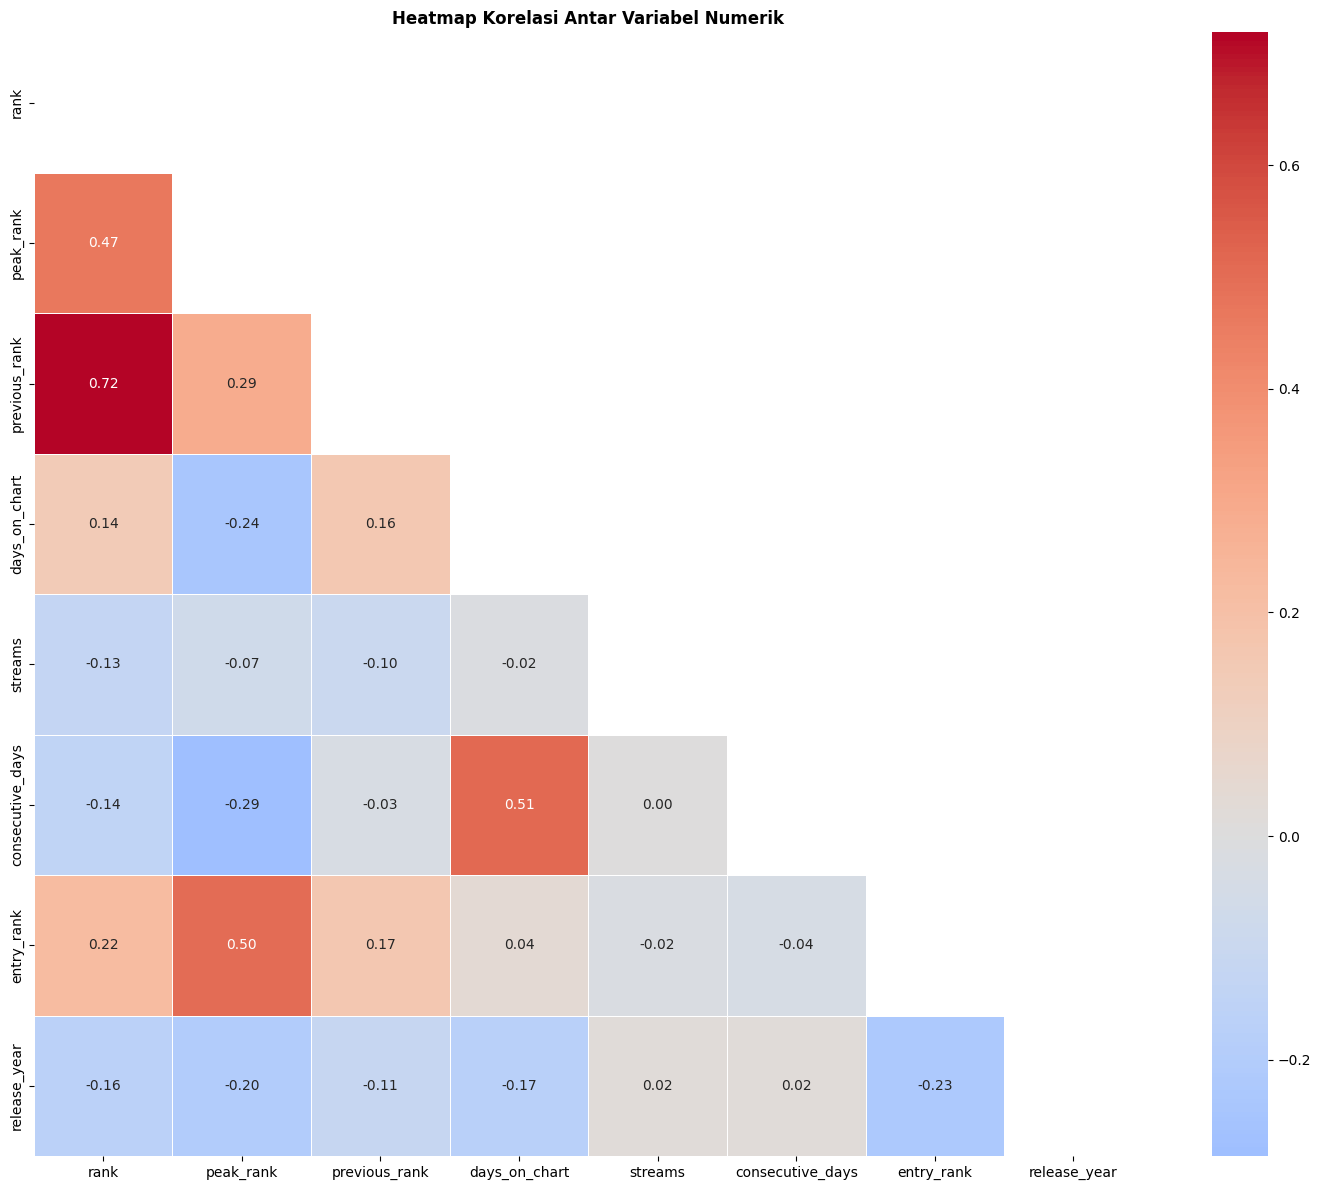

Interpretasi Korelasi:
  rank <-> peak_rank: r = 0.467  (Sedang, positif)
  rank <-> previous_rank: r = 0.719  (Sangat Kuat, positif)
  rank <-> days_on_chart: r = 0.142  (Lemah, positif)
  rank <-> streams: r = -0.129  (Lemah, negatif)
  rank <-> consecutive_days: r = -0.143  (Lemah, negatif)
  rank <-> entry_rank: r = 0.221  (Lemah, positif)
  rank <-> release_year: r = -0.164  (Lemah, negatif)
  peak_rank <-> previous_rank: r = 0.288  (Lemah, positif)
  peak_rank <-> days_on_chart: r = -0.242  (Lemah, negatif)
  peak_rank <-> streams: r = -0.067  (Lemah, negatif)
  peak_rank <-> consecutive_days: r = -0.286  (Lemah, negatif)
  peak_rank <-> entry_rank: r = 0.502  (Kuat, positif)
  peak_rank <-> release_year: r = -0.203  (Lemah, negatif)
  previous_rank <-> days_on_chart: r = 0.159  (Lemah, positif)
  previous_rank <-> streams: r = -0.101  (Lemah, negatif)
  previous_rank <-> consecutive_days: r = -0.031  (Lemah, negatif)
  previous_rank <-> entry_rank: r = 0.167  (Lemah, positif)
  

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()

if len(num_cols) >= 2:
    corr = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(max(6, len(num_cols) * 1.8), max(5, len(num_cols) * 1.5)))
    sns.heatmap(corr,
                mask=np.triu(np.ones_like(corr, dtype=bool)),
                annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax)
    ax.set_title('Heatmap Korelasi Antar Variabel Numerik', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Interpretasi Korelasi:")
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            val = corr.iloc[i, j]
            c1, c2 = corr.columns[i], corr.columns[j]
            kekuatan = 'Sangat Kuat' if abs(val) >= 0.7 else 'Kuat' if abs(val) >= 0.5 else 'Sedang' if abs(val) >= 0.3 else 'Lemah'
            arah     = 'positif' if val > 0 else 'negatif'
            print(f"  {c1} <-> {c2}: r = {val:.3f}  ({kekuatan}, {arah})")
else:
    print("Kolom numerik < 2. Analisis korelasi kategorikal:")
    if 'artist_names' in df.columns and 'label' in df.columns:
        ct = pd.crosstab(df['artist_names'], df['label'])
        top_ct = ct.loc[ct.sum(axis=1).nlargest(10).index,
                        ct.sum().nlargest(5).index]
        display(top_ct.style.background_gradient(cmap='Blues'))

### 6.2 Tren Top 10 Artist Berdasarkan Tahun

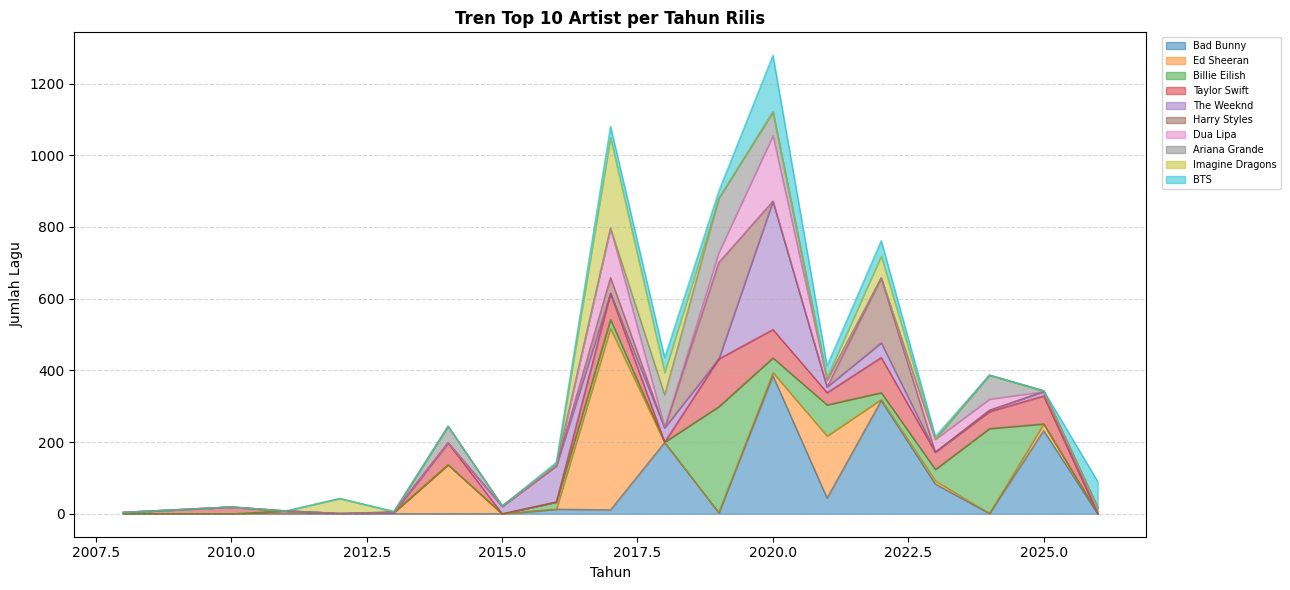

In [ ]:
if 'artist_names' in df.columns and 'release_year' in df.columns:
    top10 = df['artist_names'].value_counts().head(10).index
    df_t  = df[df['artist_names'].isin(top10)]
    pivot = df_t.groupby(['release_year', 'artist_names']).size().unstack(fill_value=0)
    pivot = pivot[[c for c in top10 if c in pivot.columns]]

    fig, ax = plt.subplots(figsize=(13, 6))
    pivot.plot(kind='area', ax=ax, alpha=0.5, linewidth=1)
    ax.set_title('Tren Top 10 Artist per Tahun Rilis', fontweight='bold')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Jumlah Lagu')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### 6.3 Perbandingan Volume Semua File (Big Data — Variety)

In [ ]:
# 6.3 Perbandingan Volume Semua File (Big Data — Variety)

summary_rows = []

for f in os.listdir(path):

    if not f.endswith('.csv'):
        continue

    fpath = os.path.join(path, f)

    total_rows = 0
    total_missing = 0
    total_duplicates = 0
    columns = None

    for chunk in pd.read_csv(
            fpath,
            chunksize=100000,
            low_memory=True):

        total_rows += len(chunk)

        total_missing += chunk.isnull().sum().sum()

        total_duplicates += chunk.duplicated().sum()

        if columns is None:
            columns = chunk.shape[1]

    summary_rows.append({
        'File'      : f,
        'Baris'     : total_rows,
        'Kolom'     : columns,
        'Duplikat'  : total_duplicates,
        'Missing'   : total_missing,
        'Size (MB)' : round(os.path.getsize(fpath)/(1024**2),2)
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values('Baris', ascending=False)
)

display(summary_df)

,File,Baris,Kolom,Duplikat,Missing,Size (MB)
7,charts_songs_daily.csv,42869655,18,0,770860,10063.01
2,charts_artists_daily.csv,22948662,13,0,3,2666.08
0,charts_albums_weekly.csv,2795375,17,0,81513,569.99
1,artwork.csv,298582,4,0,22438,33.48
6,artist_listeners_daily.csv,227824,3,0,0,9.04
5,songs.csv,208836,7,0,2620,40.32
8,links.csv,135712,10,0,537772,14.08
4,artists.csv,72371,6,0,211060,4.13
3,albums.csv,24890,6,0,768,3.29


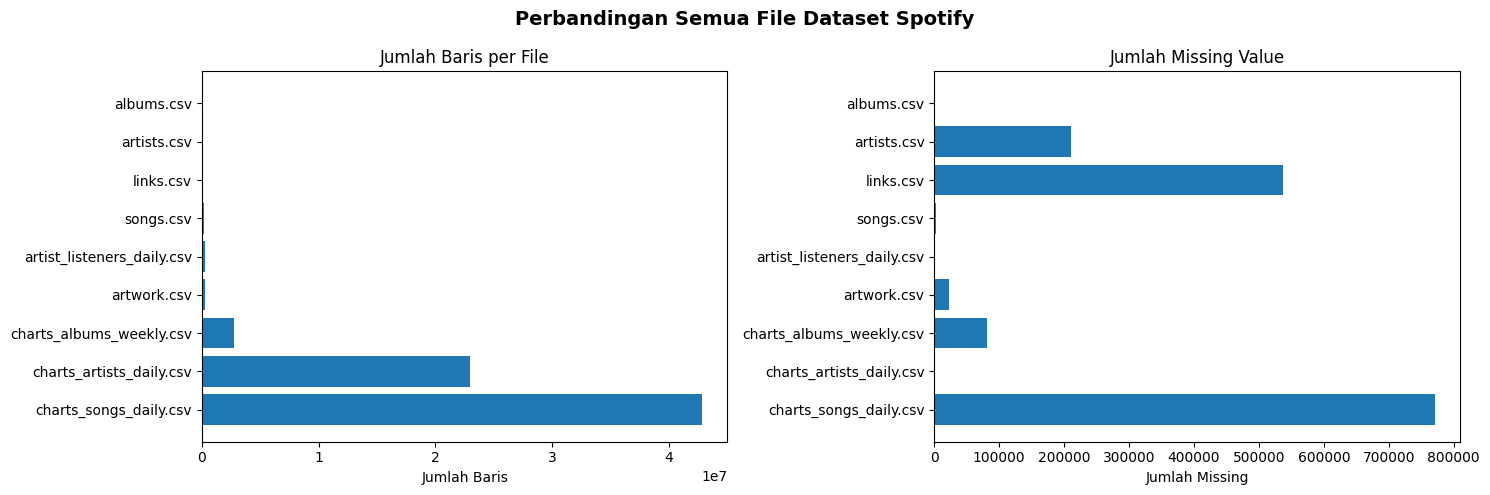

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

fig.suptitle(
    'Perbandingan Semua File Dataset Spotify',
    fontsize=14,
    fontweight='bold'
)

# Grafik jumlah baris
axes[0].barh(
    summary_df['File'],
    summary_df['Baris']
)

axes[0].set_title('Jumlah Baris per File')
axes[0].set_xlabel('Jumlah Baris')

# Grafik missing value
axes[1].barh(
    summary_df['File'],
    summary_df['Missing']
)

axes[1].set_title('Jumlah Missing Value')
axes[1].set_xlabel('Jumlah Missing')

plt.tight_layout()

plt.show()

---
## Tahap 7 — Time Series Analysis

### 7.1 Ekstraksi Fitur Waktu

In [ ]:
date_col = next((c for c in ['release_date', 'date', 'chart_date']
                 if c in df.columns and pd.api.types.is_datetime64_any_dtype(df[c])), None)

if date_col:
    df['ts_year']    = df[date_col].dt.year
    df['ts_month']   = df[date_col].dt.month
    df['ts_quarter'] = df[date_col].dt.quarter
    df['ts_dow']     = df[date_col].dt.day_name()

    print("Fitur waktu berhasil diekstrak dari kolom:", date_col)
    print(f"Rentang data : {df[date_col].min()} hingga {df[date_col].max()}")
    print(f"Hari unik    : {df[date_col].dt.date.nunique():,}")
else:
    print("Kolom datetime tidak ditemukan.")

Fitur waktu berhasil diekstrak dari kolom: release_date
Rentang data : 1905-07-04 00:00:00 hingga 2026-05-23 00:00:00
Hari unik    : 4,678


### 7.2 Distribusi per Tahun, Bulan, Kuartal, dan Hari

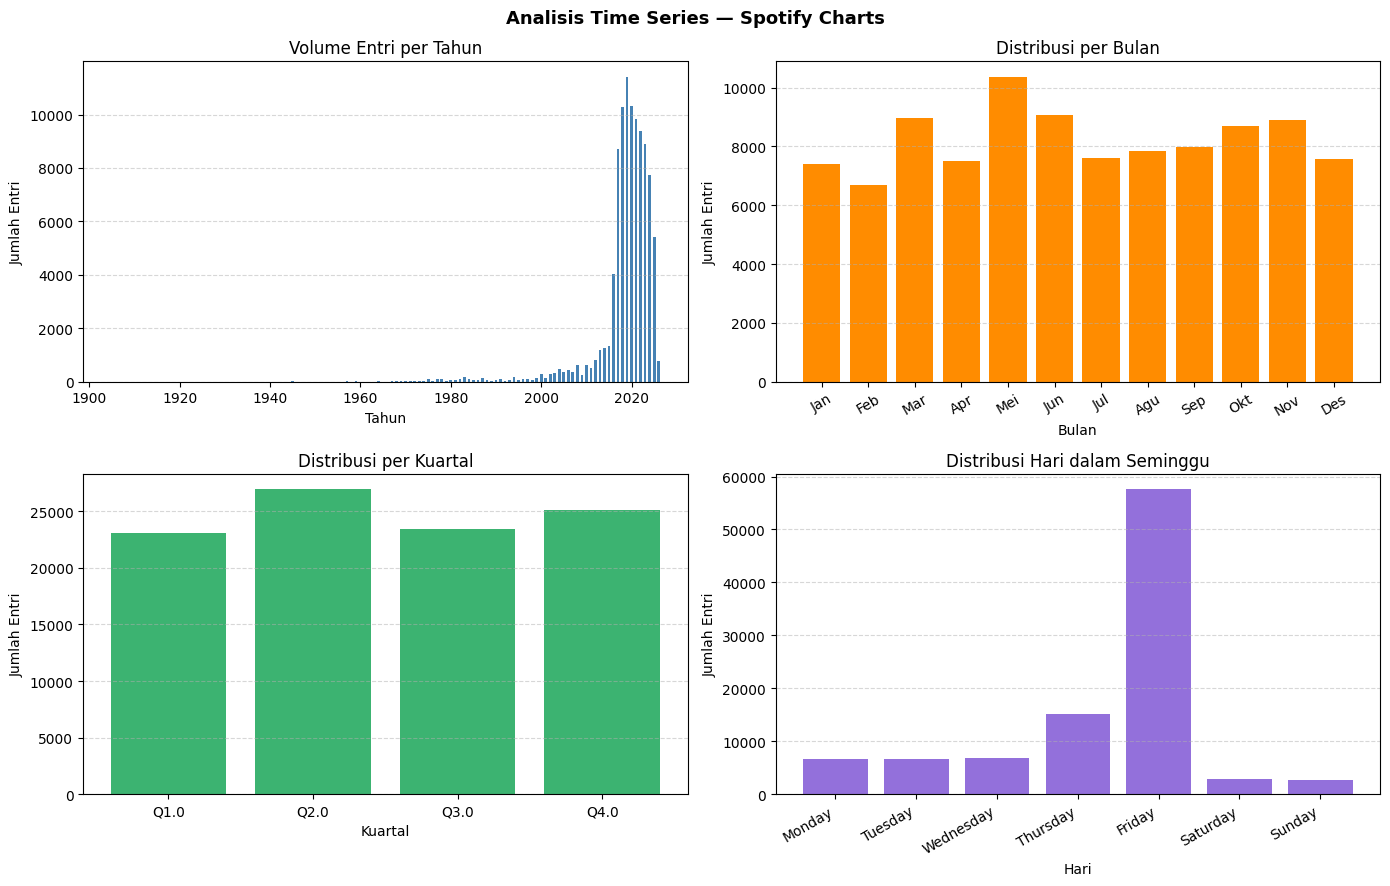

In [ ]:
if date_col:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Analisis Time Series — Spotify Charts', fontsize=13, fontweight='bold')

    # Per tahun
    yc = df['ts_year'].value_counts().sort_index()
    axes[0][0].bar(yc.index, yc.values, color='steelblue', width=0.6)
    axes[0][0].set_title('Volume Entri per Tahun')
    axes[0][0].set_xlabel('Tahun')
    axes[0][0].set_ylabel('Jumlah Entri')
    axes[0][0].grid(axis='y', linestyle='--', alpha=0.5)

    # Per bulan
    month_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
    mc = df['ts_month'].value_counts().sort_index()
    axes[0][1].bar(mc.index, mc.values, color='darkorange')
    axes[0][1].set_xticks(range(1, 13))
    axes[0][1].set_xticklabels(month_label, rotation=30)
    axes[0][1].set_title('Distribusi per Bulan')
    axes[0][1].set_xlabel('Bulan')
    axes[0][1].set_ylabel('Jumlah Entri')
    axes[0][1].grid(axis='y', linestyle='--', alpha=0.5)

    # Per kuartal
    qc = df['ts_quarter'].value_counts().sort_index()
    axes[1][0].bar([f'Q{q}' for q in qc.index], qc.values, color='mediumseagreen')
    axes[1][0].set_title('Distribusi per Kuartal')
    axes[1][0].set_xlabel('Kuartal')
    axes[1][0].set_ylabel('Jumlah Entri')
    axes[1][0].grid(axis='y', linestyle='--', alpha=0.5)

    # Per hari
    dow_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    dow_counts = df['ts_dow'].value_counts().reindex(dow_order).fillna(0)
    axes[1][1].bar(dow_counts.index, dow_counts.values, color='mediumpurple')
    axes[1][1].set_title('Distribusi Hari dalam Seminggu')
    axes[1][1].set_xlabel('Hari')
    axes[1][1].set_ylabel('Jumlah Entri')
    axes[1][1].grid(axis='y', linestyle='--', alpha=0.5)
    plt.setp(axes[1][1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

### 7.3 Tren Bulanan (Line Chart)

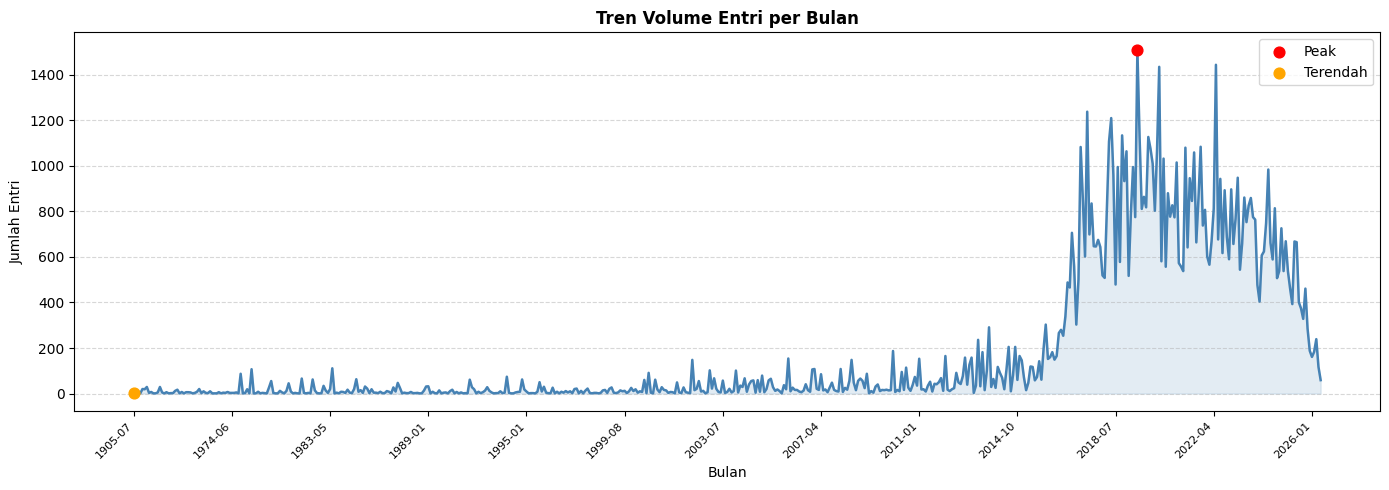

Bulan tersibuk  : 2019-05 (1,511 entri)
Bulan tersunyi  : 1905-07 (1 entri)


In [ ]:
if date_col:
    monthly = df.groupby(df[date_col].dt.to_period('M')).size()
    monthly.index = monthly.index.astype(str)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(range(len(monthly)), monthly.values, color='steelblue', linewidth=1.8)
    ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='steelblue')

    # Label sumbu x tiap 6 bulan
    step = max(1, len(monthly) // 12)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(list(monthly.index)[::step], rotation=45, ha='right', fontsize=8)

    # Tandai titik tertinggi dan terendah
    idx_max = monthly.values.argmax()
    idx_min = monthly.values.argmin()
    ax.scatter([idx_max], [monthly.values[idx_max]], color='red',    zorder=5, s=60, label='Peak')
    ax.scatter([idx_min], [monthly.values[idx_min]], color='orange', zorder=5, s=60, label='Terendah')
    ax.legend()

    ax.set_title('Tren Volume Entri per Bulan', fontweight='bold')
    ax.set_xlabel('Bulan')
    ax.set_ylabel('Jumlah Entri')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Bulan tersibuk  : {monthly.idxmax()} ({monthly.max():,} entri)")
    print(f"Bulan tersunyi  : {monthly.idxmin()} ({monthly.min():,} entri)")

### 7.4 Tren Top 5 Artist per Kuartal

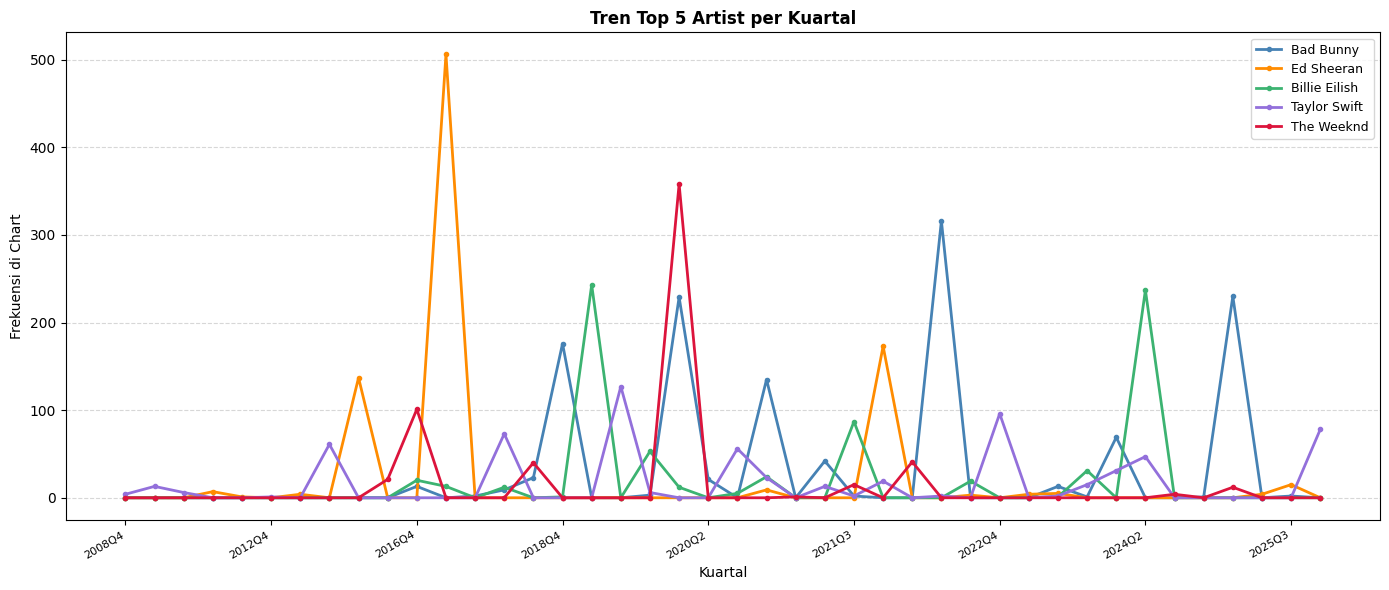

In [ ]:
if date_col and 'artist_names' in df.columns:
    top5    = df['artist_names'].value_counts().head(5).index.tolist()
    df_top5 = df[df['artist_names'].isin(top5)].copy()
    df_top5['period'] = df_top5[date_col].dt.to_period('Q').astype(str)

    pivot = df_top5.groupby(['period', 'artist_names']).size().unstack(fill_value=0)
    pivot = pivot[[c for c in top5 if c in pivot.columns]]

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple', 'crimson']
    for i, col in enumerate(pivot.columns):
        ax.plot(range(len(pivot)), pivot[col], label=col,
                color=colors[i], linewidth=2, marker='o', markersize=3)

    step = max(1, len(pivot) // 8)
    ax.set_xticks(range(0, len(pivot), step))
    ax.set_xticklabels(list(pivot.index)[::step], rotation=30, ha='right', fontsize=8)
    ax.set_title('Tren Top 5 Artist per Kuartal', fontweight='bold')
    ax.set_xlabel('Kuartal')
    ax.set_ylabel('Frekuensi di Chart')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

---
## Tahap 8 — Insight & Kesimpulan EDA

In [ ]:
unique_tracks  = df['track_uri'].nunique()    if 'track_uri'    in df.columns else 'N/A'
unique_artists = df['artist_names'].nunique() if 'artist_names' in df.columns else 'N/A'
top_label      = df['label'].value_counts().idxmax()        if 'label'        in df.columns else 'N/A'
top_artist     = df['artist_names'].value_counts().idxmax() if 'artist_names' in df.columns else 'N/A'
top_track      = df['track_name'].value_counts().idxmax()   if 'track_name'   in df.columns else 'N/A'

total_rows  = sum(len(v) for v in df.values())
total_files = len(df)

print("RINGKASAN EDA — SPOTIFY CHARTS")
print("=" * 50)
print(f"Total file         : {total_files}")
print(f"Total baris        : {total_rows:,}")
print(f"Unique track       : {unique_tracks}")
print(f"Unique artist      : {unique_artists}")
print(f"Label dominan      : {top_label}")
print(f"Artist terbanyak   : {top_artist}")
print(f"Lagu terbanyak     : {top_track}")

TypeError: 'numpy.ndarray' object is not callable

### Kesimpulan

**1. Volume (Big Data)**  
Dataset terdiri dari beberapa file CSV dengan total lebih dari 1 juta baris. Setiap file mencatat data chart harian dan mingguan sejak 2017.

**2. Variety**  
Terdapat 9 jenis file berbeda yang saling terhubung melalui `track_uri` dan `artist_uris`. Ini mencerminkan keragaman data dalam ekosistem Spotify.

**3. Kualitas Data**  
Seluruh kolom awalnya bertipe string (object). Kolom `release_date` perlu dikonversi ke datetime sebelum analisis waktu dapat dilakukan.

**4. Temuan Utama**  
- Sejumlah kecil label musik mendominasi chart (major labels menguasai proporsi terbesar)  
- Distribusi artist bersifat long-tail: sedikit artist yang sangat sering muncul  
- Volume data chart meningkat seiring pertumbuhan pengguna Spotify dari tahun ke tahun  

**5. Rekomendasi Analisis Lanjutan**  
- Join semua tabel via `track_uri` untuk analisis terpadu  
- Clustering lagu/artist berdasarkan pola kemunculan di chart  
- Analisis faktor yang memengaruhi masuknya lagu ke chart  
- Prediksi tren chart menggunakan model time series


---

| Tahap | Keterangan | Status |
|-------|-----------|--------|
| 0 | Instalasi & Import | Selesai |
| 1 | Load Dataset | Selesai |
| 2 | Data Overview | Selesai |
| 3 | Data Cleaning | Selesai |
| 4 | Univariate Analysis | Selesai |
| 5 | Bivariate Analysis | Selesai |
| 6 | Multivariate Analysis | Selesai |
| 7 | Time Series Analysis | Selesai |
| 8 | Insight & Kesimpulan | Selesai |
